In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

In [5]:
df = pd.read_csv("Downloads/HI-Small_Trans.csv")
print("Dataset shape:", df.shape)
print(df.columns.tolist())

print("\nClass distribution:")
print(df["Is Laundering"].value_counts())


Dataset shape: (5078345, 11)
['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering']

Class distribution:
Is Laundering
0    5073168
1       5177
Name: count, dtype: int64


In [4]:
model_df = df.copy()

In [6]:
model_df["Timestamp"] = pd.to_datetime(
    model_df["Timestamp"]
)
model_df["Hour"] = model_df["Timestamp"].dt.hour
model_df["DayOfWeek"] = model_df["Timestamp"].dt.dayofweek
model_df["Day"] = model_df["Timestamp"].dt.day
model_df["Month"] = model_df["Timestamp"].dt.month

In [7]:
model_df["Amount Received"] = np.log1p(
    model_df["Amount Received"]
)

model_df["Amount Paid"] = np.log1p(
    model_df["Amount Paid"]
)

In [8]:
model_df = model_df.drop(
    columns=[
        "Timestamp",
        "Account",
        "Account.1",
        "From Bank",
        "To Bank"
    ]
)

In [9]:
print(model_df.columns)

Index(['Amount Received', 'Receiving Currency', 'Amount Paid',
       'Payment Currency', 'Payment Format', 'Is Laundering', 'Hour',
       'DayOfWeek', 'Day', 'Month'],
      dtype='str')


In [10]:
X = model_df.drop(
    columns=["Is Laundering"]
)

y = model_df["Is Laundering"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [12]:
print("TRAIN:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

print("\nTEST:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True) * 100)

TRAIN:
Is Laundering
0    4058534
1       4142
Name: count, dtype: int64
Is Laundering
0    99.898047
1     0.101953
Name: proportion, dtype: float64

TEST:
Is Laundering
0    1014634
1       1035
Name: count, dtype: int64
Is Laundering
0    99.898097
1     0.101903
Name: proportion, dtype: float64


In [13]:
numeric_features = [
    "Amount Received",
    "Amount Paid",
    "Hour",
    "DayOfWeek",
    "Day",
    "Month"
]

categorical_features = [
    "Receiving Currency",
    "Payment Currency",
    "Payment Format"
]

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [15]:
linear_svm = LinearSVC(
    C=1.0,
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

In [16]:
linear_svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", linear_svm)
])

In [17]:
print("Training Linear SVM...")

linear_svm_pipeline.fit(
    X_train,
    y_train
)

print("Training completed.")

Training Linear SVM...
Training completed.


In [18]:
linear_pred = linear_svm_pipeline.predict(
    X_test
)

linear_score = linear_svm_pipeline.decision_function(
    X_test
)

In [19]:
print(
    classification_report(
        y_test,
        linear_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9999    0.8876    0.9404   1014634
           1     0.0079    0.8783    0.0157      1035

    accuracy                         0.8876   1015669
   macro avg     0.5039    0.8830    0.4780   1015669
weighted avg     0.9988    0.8876    0.9395   1015669



In [20]:
linear_accuracy = accuracy_score(
    y_test,
    linear_pred
)

linear_precision = precision_score(
    y_test,
    linear_pred,
    zero_division=0
)

linear_recall = recall_score(
    y_test,
    linear_pred,
    zero_division=0
)

linear_f1 = f1_score(
    y_test,
    linear_pred,
    zero_division=0
)

linear_roc = roc_auc_score(
    y_test,
    linear_score
)

linear_pr = average_precision_score(
    y_test,
    linear_score
)

print("Linear SVM")
print("-----------------------")
print("Accuracy :", linear_accuracy)
print("Precision:", linear_precision)
print("Recall   :", linear_recall)
print("F1       :", linear_f1)
print("ROC-AUC  :", linear_roc)
print("PR-AUC   :", linear_pr)

Linear SVM
-----------------------
Accuracy : 0.8876297297643229
Precision: 0.00791026332735785
Recall   : 0.8782608695652174
F1       : 0.01567930728164969
ROC-AUC  : 0.9221449567893019
PR-AUC   : 0.014066952911165921


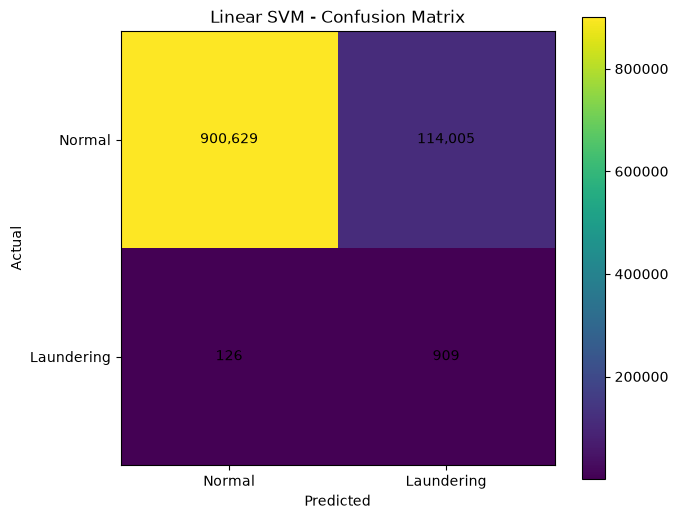

In [21]:
cm = confusion_matrix(
    y_test,
    linear_pred
)

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title("Linear SVM - Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Normal", "Laundering"]
)

plt.yticks(
    [0, 1],
    ["Normal", "Laundering"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

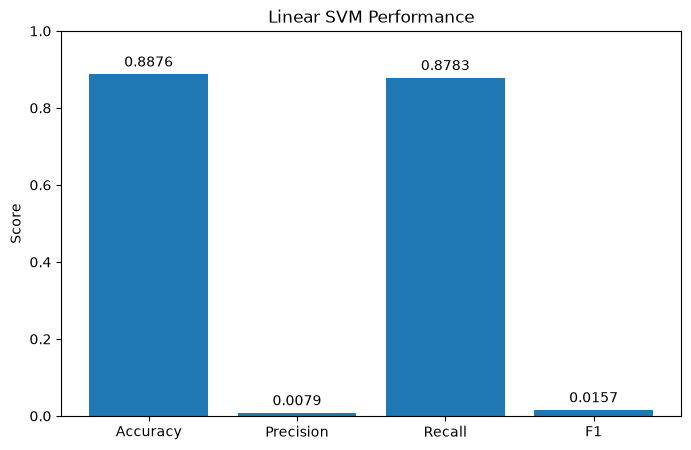

In [22]:
linear_metrics = {
    "Accuracy": linear_accuracy,
    "Precision": linear_precision,
    "Recall": linear_recall,
    "F1": linear_f1
}

plt.figure(figsize=(8, 5))

bars = plt.bar(
    linear_metrics.keys(),
    linear_metrics.values()
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Linear SVM Performance")

for bar, value in zip(
    bars,
    linear_metrics.values()
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.4f}",
        ha="center"
    )

plt.show()

In [23]:
normal_df = df[
    df["Is Laundering"] == 0
]

laundering_df = df[
    df["Is Laundering"] == 1
]

In [24]:
normal_sample = normal_df.sample(
    n=9 * len(laundering_df),
    random_state=42
)

In [25]:
df_90_10 = pd.concat(
    [
        normal_sample,
        laundering_df
    ],
    ignore_index=True
)

In [26]:
df_90_10 = df_90_10.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [27]:
print(
    df_90_10["Is Laundering"].value_counts()
)

print(
    df_90_10["Is Laundering"]
    .value_counts(normalize=True) * 100
)

Is Laundering
0    46593
1     5177
Name: count, dtype: int64
Is Laundering
0    90.0
1    10.0
Name: proportion, dtype: float64


In [28]:
model_90 = df_90_10.copy()

model_90["Timestamp"] = pd.to_datetime(
    model_90["Timestamp"]
)

model_90["Hour"] = model_90[
    "Timestamp"
].dt.hour

model_90["DayOfWeek"] = model_90[
    "Timestamp"
].dt.dayofweek

model_90["Day"] = model_90[
    "Timestamp"
].dt.day

model_90["Month"] = model_90[
    "Timestamp"
].dt.month

In [29]:
model_90["Amount Received"] = np.log1p(
    model_90["Amount Received"]
)

model_90["Amount Paid"] = np.log1p(
    model_90["Amount Paid"]
)

In [30]:
model_90 = model_90.drop(
    columns=[
        "Timestamp",
        "Account",
        "Account.1",
        "From Bank",
        "To Bank"
    ]
)

In [31]:
X90 = model_90.drop(
    columns=["Is Laundering"]
)

y90 = model_90["Is Laundering"]

In [32]:
X90_train, X90_test, y90_train, y90_test = train_test_split(
    X90,
    y90,
    test_size=0.20,
    stratify=y90,
    random_state=42
)

In [33]:
print("Training:")
print(
    y90_train.value_counts(
        normalize=True
    ) * 100
)

print("\nTesting:")
print(
    y90_test.value_counts(
        normalize=True
    ) * 100
)

Training:
Is Laundering
0    89.999034
1    10.000966
Name: proportion, dtype: float64

Testing:
Is Laundering
0    90.003863
1     9.996137
Name: proportion, dtype: float64


In [34]:
nonlinear_svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=False,
    random_state=42
)

In [35]:
nonlinear_svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", nonlinear_svm)
])

In [36]:
print("Training RBF SVM...")

nonlinear_svm_pipeline.fit(
    X90_train,
    y90_train
)

print("RBF SVM training completed.")

Training RBF SVM...


C:\Users\spars\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


RBF SVM training completed.


In [37]:
rbf_pred = nonlinear_svm_pipeline.predict(
    X90_test
)

rbf_score = nonlinear_svm_pipeline.decision_function(
    X90_test
)

In [38]:
print(
    classification_report(
        y90_test,
        rbf_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9602    0.9691    0.9646      9319
           1     0.6965    0.6386    0.6663      1035

    accuracy                         0.9361     10354
   macro avg     0.8284    0.8039    0.8155     10354
weighted avg     0.9339    0.9361    0.9348     10354



In [39]:
rbf_accuracy = accuracy_score(
    y90_test,
    rbf_pred
)

rbf_precision = precision_score(
    y90_test,
    rbf_pred
)

rbf_recall = recall_score(
    y90_test,
    rbf_pred
)

rbf_f1 = f1_score(
    y90_test,
    rbf_pred
)

rbf_roc = roc_auc_score(
    y90_test,
    rbf_score
)

rbf_pr = average_precision_score(
    y90_test,
    rbf_score
)

print("RBF SVM")
print("-----------------------")
print("Accuracy :", rbf_accuracy)
print("Precision:", rbf_precision)
print("Recall   :", rbf_recall)
print("F1       :", rbf_f1)
print("ROC-AUC  :", rbf_roc)
print("PR-AUC   :", rbf_pr)

RBF SVM
-----------------------
Accuracy : 0.9360633571566545
Precision: 0.6965226554267651
Recall   : 0.6386473429951691
F1       : 0.6663306451612904
ROC-AUC  : 0.8877850197482365
PR-AUC   : 0.7011395238006193


In [40]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC"
    ],

    "Linear SVM": [
        linear_accuracy,
        linear_precision,
        linear_recall,
        linear_f1,
        linear_roc,
        linear_pr
    ],

    "RBF SVM 90:10": [
        rbf_accuracy,
        rbf_precision,
        rbf_recall,
        rbf_f1,
        rbf_roc,
        rbf_pr
    ]
})

print(comparison)

      Metric  Linear SVM  RBF SVM 90:10
0   Accuracy    0.887630       0.936063
1  Precision    0.007910       0.696523
2     Recall    0.878261       0.638647
3         F1    0.015679       0.666331
4    ROC-AUC    0.922145       0.887785
5     PR-AUC    0.014067       0.701140


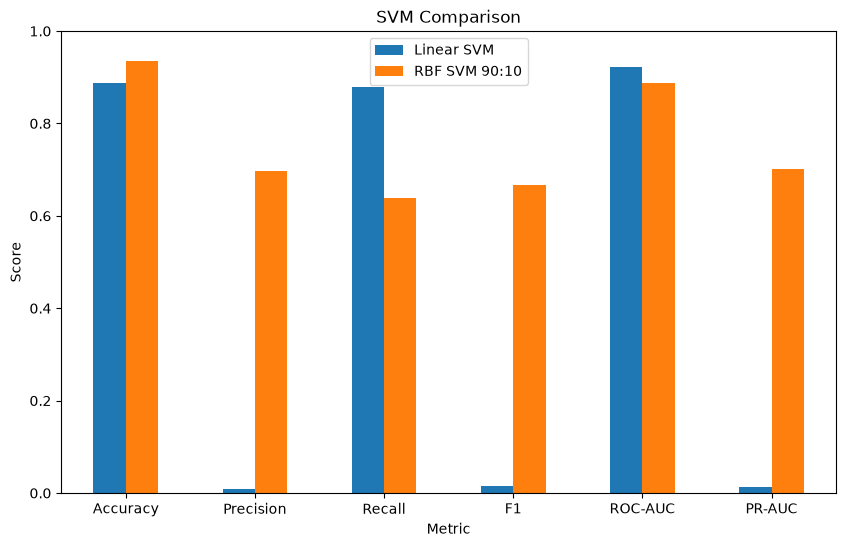

In [41]:
comparison_plot = comparison.set_index(
    "Metric"
)

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("SVM Comparison")
plt.xticks(rotation=0)
plt.legend()
plt.show()